# Install Aerosandbox
Run the cell below when you open this file or if you restart the kernel/session

In [53]:
!pip install aerosandbox

# Creating power and thrust fit from prop chart
Run the cell below when you open this file or if you restart the kernel/session

In [54]:
import pandas as pd
import numpy as np
from casadi import MX, vertcat, Function


def load_prop_data(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()

    data_blocks = []
    current_rpm = None
    i = 0
    while i < len(lines):
        line = lines[i]
        if "PROP RPM" in line:
            try:
                current_rpm = float(line.split("=")[1])
            except:
                i += 1
                continue

            if current_rpm < 5000:
                i += 1
                continue

            i += 3
            while i < len(lines) and lines[i].strip():
                parts = lines[i].split()
                if len(parts) < 12:
                    i += 1
                    continue
                try:
                    v_mph = float(parts[0])
                    power_W = float(parts[8])
                    thrust_N = float(parts[10])
                except ValueError:
                    i += 1
                    continue

                data_blocks.append({
                    "v": v_mph * 0.44704,  # m/s
                    "rpm": current_rpm,
                    "power": power_W,
                    "thrust": thrust_N
                })
                i += 1
        else:
            i += 1

    return pd.DataFrame(data_blocks)


def fit_separable_polynomial(df, y_col, deg_v=5, deg_rpm=3):
    """
    Fit separable polynomial: y = sum(a_i*v^i) + sum(b_j*rpm^j)
    Returns: a_coeffs, b_coeffs
    """
    v = df["v"].values
    rpm = df["rpm"].values
    y = df[y_col].values

    # Design matrix: powers of v and powers of rpm
    X = np.column_stack([v**i for i in range(deg_v+1)] +
                        [rpm**j for j in range(deg_rpm+1)])

    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    a_coeffs = coeffs[:deg_v+1]
    b_coeffs = coeffs[deg_v+1:]
    return a_coeffs, b_coeffs


def build_casadi_poly(a_coeffs, b_coeffs):
    """
    Build CasADi expression for separable polynomial
    """
    v = MX.sym('v')
    rpm = MX.sym('rpm')

    expr_v = sum(a*v**i for i, a in enumerate(a_coeffs))
    expr_rpm = sum(b*rpm**j for j, b in enumerate(b_coeffs))
    expr = expr_v + expr_rpm

    # Optional: make CasADi function for fast evaluation
    f = Function('poly_func', [v, rpm], [expr])
    return f


def build_prop_model(df, deg_v=5, deg_rpm=3):
    # Fit power
    a_p, b_p = fit_separable_polynomial(df, "power", deg_v, deg_rpm)
    # Fit thrust
    a_t, b_t = fit_separable_polynomial(df, "thrust", deg_v, deg_rpm)

    # Build CasADi functions
    power_func = build_casadi_poly(a_p, b_p)
    thrust_func = build_casadi_poly(a_t, b_t)

    return power_func, thrust_func, (a_p, b_p), (a_t, b_t)



# Main QAPOT Code

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        8
Number of nonzeros in inequality constraint Jacobian.:       38
Number of nonzeros in Lagrangian Hessian.............:       24

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:       19
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:       10
        inequality constraints with only upper bounds:        7

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -3.5864680e+01 4.68e+01 1.85e+01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

,CL_limit,stall_margin,time_bonus,mission_time_s,payload_kg,payload_lb,cruise_speed_mps,stall_speed_mps,cruise_CL,wing_area_m2,wing_loading,score
0,0.6,1.910,1.0,103.261,0.578,1.275,16.454,8.615,0.577,0.194,80.0,40.71
1,0.7,1.844,1.0,96.748,0.578,1.275,15.889,8.615,0.619,0.194,80.0,40.71
2,0.8,1.798,1.0,108.392,0.578,1.275,15.492,8.615,0.651,0.194,80.0,40.71
3,0.9,1.767,1.0,117.957,0.578,1.275,15.224,8.615,0.674,0.194,80.0,40.71
4,1.0,1.746,1.0,118.257,0.578,1.275,15.045,8.615,0.690,0.194,80.0,40.71


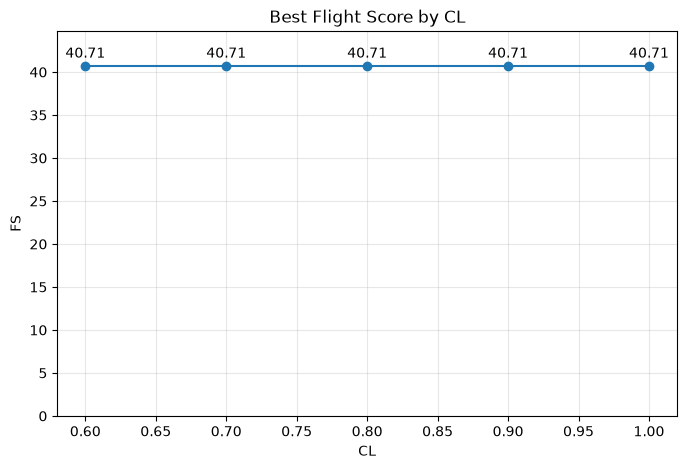

        Wingspan =  0.91 m
           Chord =  0.21 m
           Taper =  0.60
   Planform area =  0.19 m^2
    Aspect Ratio =  4.30
   Aircraft Mass =  1.01 kg
  B/n tail booms =  0.20 m


       Cruise CL =  0.69
      Cruise AOA =  4.6
        Flaps CL =  1.45
       Flaps AOA =  3.0


        P-number =  1
   Usable Energy =  15.83 Wh
   Propeller PRM =  6253 RPM
       Power Req =  47 W
 Power from Prop =  191 W
            Drag =  3.2 N
          Thrust =  5.4 N
     Corner Drag =  8.7 N
     Loiter Drag =  2.9 N
     Loiter Lift =  15.6 N


            Overall Mass = 1.588 kg
            Payload Mass = 0.578 kg
           Aircraft Mass = 1.009 kg

--- Fixed Components ---
             Battery Mass = 0.18 kg
         Electronics Mass = 0.261 kg
       Motors + ESCs Mass = 0.18 kg
               Servo Mass = 0.08 kg

--- Wing Structure ---
          Wing Spar Mass = 0.035 kg
           Wing Rib Mass = 0.012 kg
      Wing Covering Mass = 0.102 kg
         Total Wing Mass = 0.149 kg

--- Tail Structure ---
 Horizontal Spar Mass = 0.019 kg
  Horizontal Rib Mass = 0.0 kg
Horizontal Cover Mass = 0.004 kg
   Vertical Spar Mass = 0.012 kg
    Vertical Rib Mass = 0.0 kg
  Vertical Cover Mass = 0.003 kg
          Tail Boom Mass = 0.033 kg
         Total Tail Mass = 0.159 kg


         Flight Score = 40.71
         Mission Time = 150 s
       Mission Energy = 11.281 Wh
Usable Battery Energy = 19.166 Wh
      Cruise airspeed =  15.0 m/s
      Stall airspeed =  8.6 m/s
      Corner airspeed =  22.1 m/s maximum with flaps
      Loiter airspeed =  12.8 m/s
         Cruise Range =  2257 m
     Cornering Radius =  18 m minimum
           Bank Angle =  71 deg maximum


   Tail Length (arm) =  0.36 m
       Static Margin =  12.0
            LE to NP =  0.06 m
    LE to desired CG =  0.03 m
Tail Horiz Vol Coeff =  0.072
     Tail Horiz Area =  0.010 m^2
 Tail Vert Vol Coeff =  0.025
      Tail Vert Area =  0.012 m^2
          Tail chord =  0.050 m
          Tail Angle =  -6.1
           Tail Span =  0.20 m


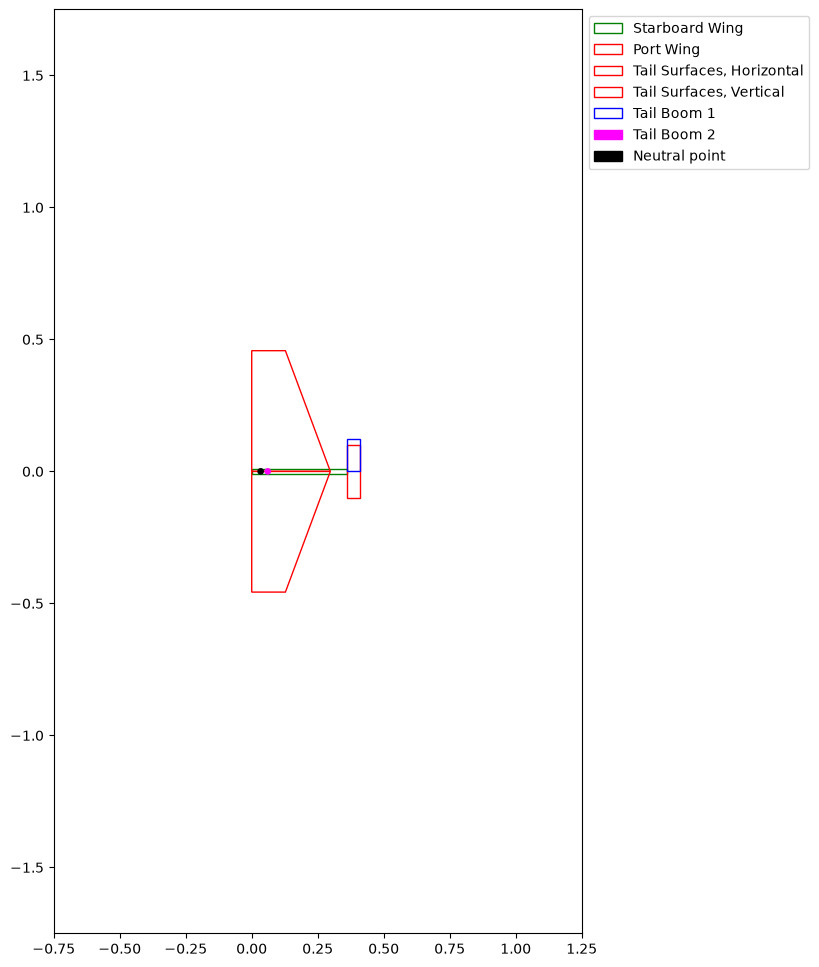

In [55]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Welcome to QAPOT - Queen's Aircraft Performance Optimization Tool

Created on Wed Nov 29 22:26:35 2023
Modified on Tues Sept 22 by Bella Reed for 2026/2027 QADT SAE

@author: Will Conway
"""
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*a numpy function was called on a casadi value.*",
    category=FutureWarning
)
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Polygon
from IPython.display import display, HTML

opti = asb.Opti()  # initialize optimization environment

### Constants - CHANGE THESE TO DESIGN AIRCRAFT

    # Atmospheric Constraints
rho = 1.225  # standard day air density - kg/m^3 Do not touch!
mu = 1.81e-5  # dynamic viscosity of the air - kg/(m·s) Do not touch!
g = 9.8  # gravitational constant - m/s^2 Do not touch!

    # Aircraft Design Characteristics - VSPAERO stuff needs to change
# CHANGE ME
# Fuselage/Wing/Tail Drag as per OPENVSP
Cd_f0 = 0.02549  # Fuselage Drag coefficient as calculated in VSPAERO (USE WING REF AREA for Calc)
Cd_w0 = 0 #0.01  # Wing parasitic drag coefficient as calculated in VSPAERO
Cd_t0 = 0 #0.003  # Tail parasitic drag coefficient as calculated in VSPAERO
fus_width = 0.15  # width of fuselage (reduces lifting section of wing span)

Cl_max = 1.5  # stall condition (this should be at takeoff or VTOL transition)
#v_min = 8  # m/s stall condition (this should be at takeoff or VTOL transition speed)
#thicc  = 0.12  # Thickness of airfoil as % of chord
ARh = 6  # Horizontal Stab Aspect Ratio
ARv = 3  # Vertical Stab Aspect Ratio
e = 0.8  # Oswalds efficiency, generally accepted value
#CHANGE ME
tail_type = 'v'


    # Mission Params
time_total = 150 # s (4 min flight time window)
#CHANGE AFTER ELECTRONICS MEETING
energy_cap = 110 # Wh
throttle_cruise = 0.65 # what throttle setting (0-1) we want to cruise at

    # Aircraft Material Properties
    # Updated with Structures info 2026/09/21
LdSpar = 0.038 # Linear density of spar materials. This should be kg/m
LdSparTail = 0.093 # Linear density of tail spar materials. This should be kg/m
LdRib = 0.8 # Linear density of rib materials. This should be kg/m^2
RibsPerSpan = 6 # Number of wing ribs per meter
CFDensity = 0.75 # Weight of skin material. This should be in kg/m^2
ShrinkDensity = 0.03
foamdensity = 0 # density of foam used for inner section. This should be in kg/m^3
#!!!
#need percentages from structures
CFWingFraction = 0.25
CFTailFraction = 0.25



#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_     DESIGN VARIABLES - Variables we want to find    #_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_

AR = opti.variable(init_guess=10)
ARh = opti.variable(init_guess=7)
S = opti.variable(init_guess=0.75)
Ltail = opti.variable(init_guess=1)
c_tail = opti.variable(init_guess=0.2)
v = opti.variable(init_guess=20)
alpha_g = opti.variable(init_guess=2)
alpha_g_flaps = opti.variable(init_guess=2)
#added variables to optimize for
time = opti.variable(init_guess=200)
flight_score = opti.variable(init_guess=5)
m_payload = opti.variable(init_guess=0.5)

# Now apply bounds as constraints:
opti.subject_to([
    opti.bounded(4, AR, 15),
    opti.bounded(4, ARh, 10),
    opti.bounded(0.05, S, 1.5),
    opti.bounded(0.1, Ltail, 2.0),
    opti.bounded(0.05, c_tail, 0.4),
    opti.bounded(5, v, 40),
    opti.bounded(-2, alpha_g, 8),
    opti.bounded(-2, alpha_g_flaps, 8),
    opti.bounded(0, time, 240),
    # opti.bounded(0, flight_score, 228),
    opti.bounded(0, m_payload, 1)
])

taper_ratio = 0.6


# __=__=__=__=__=__=__=__=__=__=__=__=__=__=   BATTERY INFORMATION   __=__=__=__=__=__=__=__=__=__=__=__=__=__=__=__=__=__=

#https://www.gaoneng.shop/products/gaoneng-gnb-lihv-4s-15.2v-1850mah-120c-xt60-lipo-battery-longrange
# GNB 1850 mAh 4S 120C battery

p_number = 1               # one battery pack

volts_per_cell = 3.7       # V nominal
volts_tot = 14.8           # V, 4S nominal voltage

Ah_per_cell = 1.85         # Ah
Ah = Ah_per_cell           # one 4S1P pack

energy_cap = volts_tot * Ah    # Wh

battery_mass = 0.180       # kg
weight_battery = battery_mass * g   # N

C_rating = 120
A_max_battery = Ah * C_rating       # A theoretical battery max current
power_max_elec = volts_tot * A_max_battery   # W

electronics_mass = 0.26084
motor_mass = 0.045
esc_mass = 0.015
propulsion_hardware_mass = 3*(motor_mass+esc_mass) # kg
servo_mass = 0.0080 # kg
servo_total_mass = servo_mass*10 # times number of servos

    # Payload + Weights Properties
payload_weight = 0.5669905 # 1.25 lb to kg
fixed_mass = (
    battery_mass
    + propulsion_hardware_mass
    + servo_total_mass
    + electronics_mass
)

weight_fixed = fixed_mass*g
energy_elec = 80  # W, 80 watts continuous for onboard computers - should be updated


# {}{}{}{}{}{}{}{}{}{}{}{}{}{}{}{}{}  ANGLE OF ATTACK AND COEFFICIENT OF LIFT  {}{}{}{}{}{}{}{}{}{}{}{}{}{}{}{}{}{}

# FILL IN these based on airfoilTools or XFLR5
# currently using NACA 2412 - http://www.airfoiltools.com/polar/details?polar=xf-naca2412-il-500000

a_o = 5.967  # 2d lift curve slope - should really make this a function that finds the slope.
alpha_zero = np.deg2rad(2.25)  # angle of attack at 2d CL = 0 ... ideally this should be not hardcoded, like Cl_range....

# uncomment line below if not optimizing taper
# Cla = 0.1043 # in degrees using excel trendline - slope for angle of attack to coefficient of lift
# CLa = Cla / (1 + Cla/(np.pi * AR))
# Cl_cruise = CLa*alpha_g + 0.2508  # got equation using excel trendline - good up to 10 deg.

airfoil_choice = 1;

if airfoil_choice == 1: #2412
    a_o = 5.116513  #2D lift curve slope in rad
    alpha_zero = np.deg2rad(1.78)  # Zero-lift angle in radians
    Cla = 0.1097  #Lift slope in degrees
    offset = 0.194  #Offset for Cl calculation
    Cl_max = 1.25
    Stall_aoa = 11.97 #degrees
    thicc = 0.12
    #flaps
    a_o_flaps = 4.77  #2D lift curve slope in rad
    alpha_zero_flaps = np.deg2rad(14.5)  # Zero-lift angle in radians
    Cla_flaps = 0.0833  #Lift slope in degrees
    offset_flaps = 1.2  #Offset for Cl calculation
    Cl_max_flaps = 1.76
    Stall_aoa_flaps = 8.9


elif airfoil_choice == 2: #23012
    a_o = 4.967544
    alpha_zero = np.deg2rad(3.03)
    Cla = 0.0893
    offset = 0.271
    Cl_max = 1.30
    Stall_aoa = 12.9
    thicc = 0.12
    #flaps
    a_o_flaps = 4.62
    alpha_zero_flaps = np.deg2rad(15.37)
    Cla_flaps = 0.0807
    offset_flaps = 1.24
    Cl_max_flaps = 1.95
    Stall_aoa_flaps = 8.78

elif airfoil_choice == 3: #23015
    a_o = 4.967544
    alpha_zero = np.deg2rad(3.591)
    Cla = 0.0867
    offset = 0.3145
    Cl_max = 1.05
    Stall_aoa = 10.07
    thicc = 0.15
     #flaps
    a_o_flaps = 4.27
    alpha_zero_flaps = np.deg2rad(15.29)
    Cla_flaps = 0.0746
    offset_flaps = 1.14
    Cl_max_flaps = 1.97
    Stall_aoa_flaps = 11.1

elif airfoil_choice == 4: #4412
    a_o = 6.388479
    alpha_zero = np.deg2rad(3.513)
    Cla = 0.1115
    offset = 0.3918
    Cl_max = 1.36
    Stall_aoa = 9.91
    thicc = 0.12
    #flaps
    a_o_flaps = 4.07
    alpha_zero_flaps = np.deg2rad(18.09)
    Cla_flaps = 0.0711
    offset_flaps = 1.29
    Cl_max_flaps = 1.79
    Stall_aoa_flaps = 7.1

elif airfoil_choice == 5: #6409
    a_o = 7.191
    alpha_zero = np.deg2rad(4.23)
    Cla = 0.1255
    offset = 0.5316
    Cl_max = 1.50
    Stall_aoa = 8.5
    #the lift curve with flaps is too crazy to use
    thicc = 0.09

# Calculate CLa with the selected Cla value
CLa = Cla / (1 + Cla / (np.pi * AR))  # Adjusted lift curve slope with aspect ratio

Cl_cruise = CLa * alpha_g + offset
# <><><><><><><><><><><><><><><><><><><><><>   PROPULSION SIZING   <><><><><><><><><><><><><><><><><><><><><><><>

# Using this motor: https://ca.robotshop.com/products/ligpower-antigravity-mn2806-evo-kv650-high-efficiency-multirotor-uav-motor
# From the motor's propeller chart, chose APC 11x 5.5 and got the data and uploaded it here as PER3_11X55E.dat
Kv = 650 # RPM/Volt

RPM = Kv * volts_tot * throttle_cruise


## CHANGE FILE BELOW TO TRY DIFFERENT PROPELLERS - can get from https://www.apcprop.com/technical-information/performance-data/?v=3e8d115eb4b3
df = load_prop_data("PER3_11x6.dat")
power_func, thrust_func, power_coeffs, thrust_coeffs = build_prop_model(df)

# power_cruise_prop, thrust_prop = model(v, RPM)
prop_number = 2
power_cruise_prop = prop_number*power_func(v, RPM)
thrust_prop = prop_number*thrust_func(v, RPM)

gPerWatt = thrust_prop/g * 1000 / power_cruise_prop

#^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v    LIFT CALCULATIONS   ^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v^v
b = np.sqrt(S * AR)  # meters
chord = np.sqrt(S / AR)  # average chord in meters
Re = rho * v * chord / mu  # Reynolds number
lift = (S-fus_width*chord) * (0.5 * rho * (v**2) * Cl_cruise)  # Newtons of lift gen. by wing
#lift_stall = (S-fus_width*chord) * (0.5 * rho * (v_min**2) * Cl_max)  # Newtons of lift gen. at max Cl by wing


# \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\    TAIL SIZING   \/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\/\
staticMargin = 12 # in % of root chord

tailSweep = 0
wingSweep = 0
wingRoot = chord*(2-taper_ratio)
wingTip = chord*taper_ratio
wingSpanHalf = b/2

tailRoot = c_tail
tailTip = tailRoot # no taper on tail for now
distanceBetweenLE = Ltail
b_tail = ARh*c_tail
tailSpanHalf = b_tail/2


# Wing MAC (Mean Aerodynamic Chord)
W1 = wingSweep * (wingRoot + 2 * wingTip) / (3 * (wingRoot + wingTip))

# Wing quarter-chord point
W2 = wingRoot - 2 * (wingRoot - wingTip) * (0.5 * wingRoot + wingTip) / (3 * (wingRoot + wingTip))

# Wing area-weighted sweep
W3 = wingSpanHalf / 3 * (1 + 2 * wingTip / wingRoot) / (1 + wingTip / wingRoot)

# CG for wing
W4 = 0.25 * W2 + W1

# Tail MAC and related geometry
T1 = tailSweep * (tailRoot + 2 * tailTip) / (3 * (tailRoot + tailTip))
T2 = tailRoot - 2 * (tailRoot - tailTip) * (0.5 * tailRoot + tailTip) / (3 * (tailRoot + tailTip))
T3 = 0.25 * T2 + T1

D2 = distanceBetweenLE - W4 + T3

# Areas
Area1 = wingSpanHalf * (wingRoot + wingTip)
Area2 = tailSpanHalf * (tailRoot + tailTip)
Area = Area2 / Area1

# Aspect ratios
# AR = (wingSpanHalf * 2) ** 2 / Area1
ARs = (tailSpanHalf * 2) ** 2 / Area2

# Tail volume coefficients
As = 0.095 / (1 + 18.25 / ARs * 0.095)
Aw = 0.11 / (1 + 18.25 / AR * 0.11)

Vbar = Area * (D2 / W2)

N1 = 0.85 * Vbar * (As / Aw) * (1 - 35 * (Aw / AR)) * W2 + W4
N2 = N1 - staticMargin / 100 * W2

Sh = Area2
bh = b_tail
chordh = c_tail
Vh = Vbar
Vv = 0.025
Sv = Vv*S*b/Ltail

chordv = chordh  # because A tail for now
bv = (Sv/2 / chordh) #setting vertical stabiliser span

Sa = Sv + Sh
chorda = chordh
ba = Sa / chorda
thetaa = 90 - np.arctan((Sv / Sh)**0.5) * 180 / np.pi * 2


# ``````,,,,,,``````,,,,,,``````,,,,,,``````,,,,,, DRAG CALCULATIONS ,,,,,,``````,,,,,,``````,,,,,,``````,,,,,,``````

Cd_wi = (Cl_cruise ** 2) / (np.pi * AR * e) # Coefficient of induced drag for wing
Cd_ti = (Cl_cruise ** 2) / (np.pi * ARh * e) # Coefficient of induced drag for tail

drag_pred = 0.5 * rho * v**2 * S * (Cd_f0 + Cd_w0 + Cd_t0 + Cd_wi + Cd_ti)

#______()______()______()______()______()______() ELECTRICAL AND ENERGY USE ()______()______()______()______()______()______()


    # Usable Energy Calculations
energy_bat = energy_cap * 0.7 # Wh, 70% usable of total capacity

    # Parasitic Drain
energy_draw = energy_elec * time_total / 3600  # Energy used by onboard payload
energy_usable = energy_bat - energy_draw

    # Fixed Wing calculations

# assuming take-off and climb is negligible (approximating as just cruising)
power_cruise_aero = drag_pred * v
time_cruise = energy_usable / power_cruise_prop * 3600


# ~~~___~~~___~~~___~~~___~~~___~~~___   COMPONENT WEIGHT MODELLING ___~~~___~~~___~~~___~~~___~~~___~~~___~~~

    # Wing Weight Model
sparweight = LdSpar * b # kg
ribweight = LdRib * chord * (chord * thicc / 2) * (RibsPerSpan * b) # kg
coveringweight = (
    CFWingFraction * CFDensity
    + (1 - CFWingFraction) * ShrinkDensity
) * b * chord * 2.5

foamweight = (chord * thicc / 2) * b * foamdensity # kg
wingweight = g * (sparweight + ribweight + coveringweight)# N

    # Horizontal Tail Calc
hsparweight = LdSparTail * bh # kg
hribweight =  LdRib * chordh * ( chordh *  thicc / 2) *  RibsPerSpan *  bh # kg
hcoveringweight =  (
    CFTailFraction * CFDensity
    + (1-CFTailFraction) * ShrinkDensity
) * bh *  chordh * 2  # kg
hfoamweight =  foamdensity *  bh *  chordh * ( chordh *  thicc / 2) # kg

    # Vertical Tail Calc
vsparweight =  LdSparTail *  bv # kg
vribweight =  LdRib *  chordv * ( chordv *  thicc / 2) *  RibsPerSpan *  bv # kg
vcoveringweight =  (
    CFTailFraction * CFDensity
    + (1-CFTailFraction) * ShrinkDensity
) * bv *  chordv * 2  # kg
vfoamweight =  foamdensity *  bv *  chordv * ( chordv *  thicc / 2) # kg

    # A-tail Calc
asparweight = LdSparTail * ba # kg
aribweight =  LdRib * chorda * ( chorda *  thicc / 2) *  RibsPerSpan *  ba # kg
acoveringweight = (
    CFTailFraction * CFDensity
    + (1 - CFTailFraction) * ShrinkDensity
) * ba * chorda * 2

# Sum Tail Weights
if tail_type == 'a' or tail_type == 'v':
    tailweight = g * ((2 * (asparweight +  aribweight +  acoveringweight)) + (LdSparTail *  Ltail * 1.7)) # N USE THIS FOR ATAIL CONFIG

else:
    tailweight = g * (hsparweight +  hribweight +  hcoveringweight +  vsparweight +  vribweight +  vcoveringweight + ( LdSparTail *  Ltail)) # N

weight = wingweight + tailweight + weight_fixed
w_total = m_payload*g + weight #total flying weight including payload

# ~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\ FLAPS, CORNERING, LOITERING /\~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\~~~~~/\

CLa_flaps = Cla_flaps / (1 + Cla_flaps / (np.pi * AR))

CL_flaps = CLa_flaps * alpha_g_flaps + offset_flaps  # coefficient of lift of flapped section of wing while flaps are deployed
CL_unflapped = CLa*alpha_g_flaps + offset  # coefficient of lift of unflapped section of wing while flaps are deployed

loadfactor = 3  # structural limit

flap_frac = 0.3  # fraction of wing (spanwise) that has flaps (is flapped)

v_corner = np.sqrt(2*w_total*loadfactor/(rho*(CL_flaps*S*flap_frac + CL_unflapped*S*(1-flap_frac))))
v_loiter = np.sqrt(2*w_total/(rho*(CL_flaps*S*flap_frac + CL_unflapped*S*(1-flap_frac))))

r_corner = v_corner**2 / (g * np.sqrt(np.abs(loadfactor**2 - 1)))

Cd_wi_flaps = ((CL_flaps*flap_frac + CL_unflapped*(1-flap_frac)) ** 2) / (np.pi * AR * e) # Coefficient of induced drag for wing
Cd_ti_flaps = ((CL_flaps*flap_frac + CL_unflapped*(1-flap_frac)) ** 2) / (np.pi * ARh * e) # Coefficient of induced drag for tail


drag_corner = 0.5 * rho * v_corner**2 * S * (Cd_f0 + Cd_w0 + Cd_t0 + Cd_wi_flaps + Cd_ti_flaps)
drag_loiter = 0.5 * rho * v_loiter**2 * S * (Cd_f0 + Cd_w0 + Cd_t0 + Cd_wi_flaps + Cd_ti_flaps)

power_corner_aero = drag_corner*v_corner
power_loiter_aero = drag_loiter*v_loiter

lift_loiter = 0.5*rho*v_loiter**2 *(CL_flaps*flap_frac + CL_unflapped*(1-flap_frac))*S

v_stall = np.sqrt(
    2 * w_total /
    (rho * S * Cl_max_flaps)
)

# omega = v_corner/turning_radius

bank_angle = np.rad2deg(np.arccos(np.clip(1 / loadfactor, -1, 1)))

# ||||||||||||||||||||||||||||||||||||||    OPTIMIZER    |||||||||||||||||||||||||||||||||||||||||||||||||||

#payload density = lead
cl_design = opti.parameter()
# stall_margin# = 2.0
distance = 426.72 #1400 ft guesstimate
wing_loading = w_total/S # STRUCTURAL LIMITS, N/m^2
wing_loading_max = 80 # N/m^2, structural limit

cl_design_values = np.arange(0.6, 1.01, 0.1)      # e.g. [0.6, 0.8, 1.0]


s_takeoff = 1 + (2*m_payload*2.20462)
s_delivery = 1 + (8*m_payload*2.20462)
s_capture = 1 + (15*m_payload*2.20462)
s_rtb = 1 + (3*m_payload*2.20462)
tb = 1
flightscore = (s_takeoff + s_delivery + s_capture + s_rtb) + tb

mission_time = 150 #sec
propulsion_energy = power_cruise_prop * mission_time / 3600
electronics_energy = energy_elec * mission_time / 3600
mission_energy = propulsion_energy + electronics_energy


opti.subject_to([
    w_total <=  1.58757*g, # 3.5 lb max weight
    w_total == lift, # make sure we can produce sufficient lift
    drag_pred <= thrust_prop, # when cruising, we must produce as much thrust as drag
    # time_cruise >= time_total,
    Cl_cruise >= 0.1,
    Cl_cruise <= Cl_max,
    Cl_cruise <= cl_design,
    mission_energy <= energy_bat,
    wing_loading <= wing_loading_max,
    # wingspan >= 10ft = 3.048 m
    b >= 0.9144, b <= 3.048 #wingspan 3-10ft
])

dist = v * mission_time # m, max theoretical Distance travelled if cruising only

opti.maximize(flightscore)
sweep_results = []
sweep_solutions = {}

for cl_value in cl_design_values:
    opti.set_value(cl_design, float(cl_value))

    try:
        test_sol = opti.solve(max_iter=300)
        test_score = float(test_sol.value(flightscore))
        result = {
            "CL_limit": float(cl_value),
            "stall_margin": float(test_sol.value(v)/test_sol.value(v_stall)),
            "time_bonus": float(tb),
            "mission_time_s": float(test_sol.value(time)),
            "payload_kg": float(test_sol.value(m_payload)),
            "payload_lb": float(test_sol.value(m_payload)) * 2.20462,
            "cruise_speed_mps": float(test_sol.value(v)),
            "stall_speed_mps": float(test_sol.value(v_stall)),
            "cruise_CL": float(test_sol.value(Cl_cruise)),
            "wing_area_m2": float(test_sol.value(S)),
            "wing_loading": float(test_sol.value(wing_loading)),
            "score": test_score,
        }
        sweep_results.append(result)
        sweep_solutions[float(cl_value)] = test_sol
    except Exception:
        pass

sweep_df = pd.DataFrame(sweep_results)

if len(sweep_df) == 0:
    raise RuntimeError("No feasible designs were found in the sweep.")

best_by_cl = (
    sweep_df.loc[sweep_df.groupby("CL_limit")["score"].idxmax()]
    .sort_values("CL_limit")
    .reset_index(drop=True)
)

display(HTML('<p style="font-size:20px;"><b>Best Flight Score by CL</b></p>'))
display(best_by_cl.round(3))

fig_fs, ax_fs = plt.subplots(figsize=(8, 5))
ax_fs.plot(best_by_cl["CL_limit"], best_by_cl["score"], marker="o")
ax_fs.set_ylim(0, best_by_cl["score"].max() * 1.1)
for cl_value, score in zip(best_by_cl["CL_limit"], best_by_cl["score"]):
    ax_fs.annotate(f"{score:.2f}", (cl_value, score), xytext=(0, 6), textcoords="offset points", ha="center")
ax_fs.set_xlabel("CL")
ax_fs.set_ylabel("FS")
ax_fs.set_title("Best Flight Score by CL")
ax_fs.grid(True, alpha=0.3)
plt.show()

best_row = best_by_cl.loc[best_by_cl["score"].idxmax()]
sol = sweep_solutions[float(best_row["CL_limit"])]
#  - - - - - - - - - - - - - - - - - - - SIZER AND OPTIMIZER OUTPUTS - - - - - - - - - - - - - - - -

aircraft_mass = sol.value(eval("weight"))/g
cruise_time = sol.value(eval("time_cruise"))/60
tail_semispan = sol.value(eval("bh"))/2 #sol.value(eval("Sh")) / sol.value(eval("chordh")) / 2
btwn_booms = tail_semispan*2
time_final = sol.value(time) #get the numerical minimized time value
### Print Outputs
display(HTML('<p style="font-size:24px;"><b>QAPOT Outputs</b></p>'))
display(HTML('<p style="font-size:18px"><u>>Dimensions</u></p>'))
# print("-->Dimensions")
print("        Wingspan = ", '%.2f' % sol.value(eval("b")), "m")
print("           Chord = ", '%.2f' % sol.value(eval("chord")), "m")
print("           Taper = ", '%.2f' % sol.value(eval("taper_ratio")))
print("   Planform area = ", '%.2f' % sol.value(eval("S")), "m^2")
print("    Aspect Ratio = ", '%.2f' % sol.value(eval("AR")))
print("   Aircraft Mass = ", '%.2f' % aircraft_mass, "kg")
print("  B/n tail booms = ", '%.2f' % btwn_booms, 'm')

# print("\n-->Aerodynamic parameters")
display(HTML('<p style="font-size:18px"><u>>Aerodynamic Parameters</u></p>'))
# print(" Wing efficiency = ", '%.4f' % sol.value(eval("eff")))
print("       Cruise CL = ", '%.2f' % sol.value(eval("Cl_cruise"))) # 3D
print("      Cruise AOA = ", '%.1f' % sol.value(eval("alpha_g"))) # geometric angle of attack
print("        Flaps CL = ", '%.2f' % sol.value(eval("CL_flaps")))
print("       Flaps AOA = ", '%.1f' % sol.value(eval("alpha_g_flaps")))


# print("\n-->Propulsion")
display(HTML('<p style="font-size:18px"><u>>Propulsion</u></p>'))
print("        P-number = ", '%.0f' % sol.value(eval("p_number")))
print("   Usable Energy = ", '%.2f' % sol.value(eval("energy_usable")), "Wh")
print("   Propeller PRM = ", '%.0f' % sol.value(eval("RPM")), "RPM")
print("       Power Req = ", '%.0f' % sol.value(eval("power_cruise_aero")), "W")
print(" Power from Prop = ", '%.0f' % sol.value(eval("power_cruise_prop")), "W")
print("            Drag = ", '%.1f' % sol.value(eval("drag_pred")), "N")
print("          Thrust = ", '%.1f' % sol.value(eval("thrust_prop")), "N")
print("     Corner Drag = ", '%.1f' % sol.value(eval("drag_corner")), "N")
#print("   Corner Thrust = ", '%.1f' % sol.value(eval("thrust_prop_corner")), "N")
print("     Loiter Drag = ", '%.1f' % sol.value(eval("drag_loiter")), "N")
#print("   Loiter Thrust = ", '%.1f' % sol.value(eval("thrust_prop_loiter")), "N")
print("     Loiter Lift = ", '%.1f' % sol.value(eval("lift_loiter")), "N")

# print("\n-->Weight")
display(HTML('<p style="font-size:18px"><u>>Weight</u></p>'))
print("            Overall Mass =", round(float(sol.value(w_total / g)), 3), "kg")
print("            Payload Mass =", round(float(sol.value(m_payload)), 3), "kg")
print("           Aircraft Mass =", round(float(sol.value(weight / g)), 3), "kg")

print("\n--- Fixed Components ---")
print("             Battery Mass =", round(battery_mass, 3), "kg")
print("         Electronics Mass =", round(electronics_mass, 3), "kg")
print("       Motors + ESCs Mass =", round(propulsion_hardware_mass, 3), "kg")
print("               Servo Mass =", round(servo_total_mass, 3), "kg")

print("\n--- Wing Structure ---")
print("          Wing Spar Mass =", round(float(sol.value(sparweight)), 3), "kg")
print("           Wing Rib Mass =", round(float(sol.value(ribweight)), 3), "kg")
print("      Wing Covering Mass =", round(float(sol.value(coveringweight)), 3), "kg")
print("         Total Wing Mass =", round(float(sol.value(wingweight / g)), 3), "kg")

print("\n--- Tail Structure ---")
print(" Horizontal Spar Mass =", round(float(sol.value(hsparweight)), 3), "kg")
print("  Horizontal Rib Mass =", round(float(sol.value(hribweight)), 3), "kg")
print("Horizontal Cover Mass =", round(float(sol.value(hcoveringweight)), 3), "kg")

print("   Vertical Spar Mass =", round(float(sol.value(vsparweight)), 3), "kg")
print("    Vertical Rib Mass =", round(float(sol.value(vribweight)), 3), "kg")
print("  Vertical Cover Mass =", round(float(sol.value(vcoveringweight)), 3), "kg")

print("          Tail Boom Mass =", round(float(sol.value(LdSparTail * Ltail)), 3), "kg")
print("         Total Tail Mass =", round(float(sol.value(tailweight / g)), 3), "kg")

# print("\n-->Performance")
display(HTML('<p style="font-size:18px"><u>>Performance</u></p>'))
print("         Flight Score =", round(sol.value(flightscore), 3))
print("         Mission Time =", mission_time, "s")
print("       Mission Energy =", round(sol.value(mission_energy),3), "Wh")
print("Usable Battery Energy =", sol.value(energy_bat), "Wh")
print("      Cruise airspeed = ", '%.1f' % sol.value(eval("v")), 'm/s')
print(f"      Stall airspeed = {sol.value(v_stall): .1f} m/s")
print("      Corner airspeed = ", '%.1f' % sol.value(eval("v_corner")) , 'm/s', 'maximum with flaps')
print("      Loiter airspeed = ", '%.1f' % sol.value(eval("v_loiter")) , 'm/s')
print("         Cruise Range = ", '%.0f' % sol.value(eval("dist")) , 'm')
print("     Cornering Radius = ", '%.0f' % sol.value(eval("r_corner")), 'm', 'minimum')
print("           Bank Angle = ", '%.0f' % sol.value(eval("bank_angle")), 'deg', 'maximum')


# print("\n-->Stability and Tail sizing")
display(HTML('<p style="font-size:18px"><u>>Stability and Tail Sizing</u></p>'))
print("   Tail Length (arm) = ", '%.2f' % sol.value(eval("Ltail")), "m")
print("       Static Margin = ", '%.1f' % staticMargin)
print("            LE to NP = ", '%.2f' % sol.value(eval("N1")), "m")
print("    LE to desired CG = ", '%.2f' % sol.value(eval("N2")), "m")
# print("  Pitch Moment Slope = ", '%.3f' % sol.value(eval("dCmdCL")))
# print("Wing Pitching Moment = ", '%.3f' % sol.value(eval("Cmw")))
# print("Tail Pitching Moment = ", '%.3f' % sol.value(eval("Cmt")))
print("Tail Horiz Vol Coeff = ", '%.3f' % sol.value(eval("Vh")))
print("     Tail Horiz Area = ", '%.3f' % sol.value(eval("Sh")), 'm^2')
print(" Tail Vert Vol Coeff = ", '%.3f' % sol.value(eval("Vv")))
print("      Tail Vert Area = ", '%.3f' % sol.value(eval("Sv")), 'm^2')
print("          Tail chord = ", '%.3f' % sol.value(eval('chordh')), 'm')
print("          Tail Angle = ", '%.1f' % sol.value(eval("thetaa")))
print("           Tail Span = ", '%.2f' % sol.value(eval('bh')), 'm')
display(HTML('<p style="font-size:18px"><u>>Visualization Plot</u></p>'))

### Plotting & Visualization
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_aspect('equal', adjustable='box')
plt.xlim(-0.75, 1.25)
plt.ylim(-1.75,1.75)

# Wing and Tail Components
#wing = Rectangle([0,(-sol.value(eval("b"))/2)], sol.value(eval("chord")), sol.value(eval("b")), linewidth=1, edgecolor = 'r', facecolor = 'none')
wingCoords1 = [(0, 0),(0, sol.value(eval("b"))/2),(sol.value(eval("chord"))*sol.value(eval("taper_ratio")),sol.value(eval("b"))/2), ((sol.value(eval("chord")))*(2-sol.value(eval("taper_ratio"))),0 )]
wingCoords2 = [(0, 0),(0, -sol.value(eval("b"))/2),(sol.value(eval("chord"))*sol.value(eval("taper_ratio")),-sol.value(eval("b"))/2), ((sol.value(eval("chord")))*(2-sol.value(eval("taper_ratio"))),0 )]
wing1 = Polygon(wingCoords1, linewidth=1, edgecolor = 'r', facecolor = 'none')
wing2 = Polygon(wingCoords2, linewidth=1, edgecolor = 'r', facecolor = 'none')
htail = Rectangle([sol.value(eval("Ltail")),(-sol.value(eval("bh"))/2)], sol.value(eval("chordh")), sol.value(eval("bh")), linewidth=1, edgecolor = 'r', facecolor = 'none')
verttail = Rectangle([sol.value(eval("Ltail")),(0)], sol.value(eval("chordv")), sol.value(eval("bv")), linewidth=1, edgecolor = 'b', facecolor = 'none')
if tail_type == 'a' or tail_type == 'h':
    #2 booms
    tailBoom1 = Rectangle([0,(-0.01 + tail_semispan)], sol.value(eval("Ltail")), 0.02, linewidth=1, edgecolor = 'g', facecolor = 'none')
    tailBoom2 = Rectangle([0,(-0.01 - tail_semispan)], sol.value(eval("Ltail")), 0.02, linewidth=1, edgecolor = 'g', facecolor = 'none')
    ax.add_patch(tailBoom1)
    ax.add_patch(tailBoom2)
else:
  #conventional tail
  tailBoom1 = Rectangle([0,-0.01], sol.value(eval("Ltail")), 0.02, linewidth=1, edgecolor = 'g', facecolor = 'none')
  ax.add_patch(tailBoom1)
NP = Circle([sol.value(eval("N1")),0],radius=0.01, edgecolor='fuchsia', facecolor='fuchsia')
CG = Circle([sol.value(eval("N2")),0],radius=0.01, edgecolor='k', facecolor='k')
ax.add_patch(wing1)
ax.add_patch(wing2)
ax.add_patch(htail)
ax.add_patch(verttail)
ax.add_patch(NP)
ax.add_patch(CG)
legend = "Starboard Wing", "Port Wing" ,"Tail Surfaces, Horizontal", "Tail Surfaces, Vertical", "Tail Boom 1", "Tail Boom 2", "Neutral point", "Desired CG"
ax.legend(legend, loc="upper left", bbox_to_anchor=(1, 1))
# Fuselage Components
# fuse_shift = -0.2
# fuselage1 = Circle([fuse_shift+ 0,0],radius=0.075)
# fuselage2 = Rectangle([fuse_shift+0.22,-0.1085], 0.190, 0.217)
# fuselage3 = Rectangle([fuse_shift+0,-0.06], 1, 0.12)
# ax.add_patch(fuselage1)
# ax.add_patch(fuselage2)
# ax.add_patch(fuselage3)

# calibrate = Circle([2,0],0.4) # LEAVE THIS CIRCLE FIXED, use for calibration
# ax.add_patch(calibrate)
#plt.ylabel("meters, y dir")
#plt.xlabel("meters, x dir")
plt.show()